In [3]:
import csv
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from skimage.feature import hog
from sklearn.metrics import confusion_matrix

try:
    import joblib
except ImportError:
    joblib = None

try:
    import pandas as pd
except ImportError:
    pd = None


PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / 'test').exists()
    ),
    Path.cwd(),
)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def read_nonempty_lines(path: Path) -> List[str]:
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    with path.open('r', encoding='utf-8') as file:
        return [line.strip() for line in file if line.strip()]


def safe_read_age_list(path: Path) -> Optional[List[int]]:
    if not path.exists():
        return None
    ages = []
    for line in read_nonempty_lines(path):
        try:
            ages.append(int(float(line)))
        except ValueError as exc:
            raise ValueError(f'Invalid age value "{line}" in {path}') from exc
    return ages


def safe_read_string_list(path: Path) -> Optional[List[str]]:
    if not path.exists():
        return None
    return read_nonempty_lines(path)


def resolve_artifact_path(path_str: str) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path
    return (PROJECT_ROOT / path).resolve()


def sigmoid(value: float) -> float:
    value = float(np.clip(value, -50.0, 50.0))
    return float(1.0 / (1.0 + np.exp(-value)))


def load_serialized_bundle(artifact_path: Path) -> Dict:
    if artifact_path.suffix.lower() in {'.joblib', '.jl'}:
        if joblib is None:
            raise ImportError('joblib is required to load .joblib artifacts')
        bundle = joblib.load(artifact_path)
    else:
        with artifact_path.open('rb') as file:
            bundle = pickle.load(file)

    if hasattr(bundle, 'predict'):
        bundle = {'model': bundle}

    if not isinstance(bundle, dict):
        raise TypeError(
            'Serialized HOG_SVM artifact must be a sklearn estimator or a dict with at least a "model" key.'
        )

    model = bundle.get('model')
    if model is None or not hasattr(model, 'predict'):
        raise KeyError('Serialized HOG_SVM artifact must contain a valid sklearn model under key "model".')

    scaler = bundle.get('scaler')
    config = bundle.get('config', {}) or {}
    return {'model': model, 'scaler': scaler, 'config': config}


def compute_hog_feature(image_path: Path, config: Dict) -> np.ndarray:
    image = cv2.imread(str(image_path))
    if image is None:
        raise RuntimeError(f'Failed to read image: {image_path}')

    image_size = int(config['image_size'])
    gray = cv2.cvtColor(cv2.resize(image, (image_size, image_size)), cv2.COLOR_BGR2GRAY)

    feature = hog(
        gray,
        orientations=int(config['orientations']),
        pixels_per_cell=tuple(config['pixels_per_cell']),
        cells_per_block=tuple(config['cells_per_block']),
        block_norm=config['block_norm'],
    )
    return np.asarray(feature, dtype=np.float32)


def build_test_records(list_dir: Path, image_dir: Path) -> List[Dict]:
    test_name_path = list_dir / 'test_name.txt'
    test_age_path = list_dir / 'test_age.txt'
    test_dis_path = list_dir / 'test_dis.txt'

    names = read_nonempty_lines(test_name_path)
    ages = safe_read_age_list(test_age_path)
    dis_list = safe_read_string_list(test_dis_path)

    if ages is not None and len(ages) != len(names):
        raise ValueError(f'Mismatch: {test_age_path.name} has {len(ages)} rows but {test_name_path.name} has {len(names)} rows')

    if dis_list is not None and len(dis_list) != len(names):
        raise ValueError(f'Mismatch: {test_dis_path.name} has {len(dis_list)} rows but {test_name_path.name} has {len(names)} rows')

    records = []
    for idx, name in enumerate(names):
        image_path = image_dir / name
        if not image_path.exists():
            raise FileNotFoundError(f'Image listed in {test_name_path.name} not found: {image_path}')
        if image_path.suffix.lower() not in IMG_EXTS:
            raise ValueError(f'Unsupported image extension in test list: {image_path.name}')

        records.append({
            'name': name,
            'image_path': image_path,
            'age': None if ages is None else ages[idx],
            'dis': None if dis_list is None else dis_list[idx],
        })

    return records


def compute_metrics(y_true: List[int], y_pred: List[int]) -> Dict:
    tp = fp = tn = fn = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if pred_label == 1 and true_label == 1:
            tp += 1
        elif pred_label == 1 and true_label == 0:
            fp += 1
        elif pred_label == 0 and true_label == 0:
            tn += 1
        else:
            fn += 1

    total = len(y_true)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
    accuracy = (tp + tn) / max(total, 1)

    return {
        'total': total,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def run_inference(records: List[Dict], bundle: Dict, config: Dict) -> Tuple[List[Dict], Optional[Dict]]:
    model = bundle['model']
    scaler = bundle.get('scaler')
    decision_threshold = float(config['decision_threshold'])
    adult_age = int(config['adult_age'])

    rows = []
    y_true = []
    y_pred = []

    for record in records:
        feature = compute_hog_feature(record['image_path'], config)
        feature_batch = feature.reshape(1, -1)

        if scaler is not None:
            feature_batch = scaler.transform(feature_batch)

        score_array = model.decision_function(feature_batch)
        score = float(np.asarray(score_array).reshape(-1)[0])
        pred_label = int(score >= decision_threshold)

        row = {
            'name': record['name'],
            'image_path': str(record['image_path']),
            'age': record['age'],
            'dis': record['dis'],
            'svm_score': score,
            'prob_adult': sigmoid(score),
            'pred_label': pred_label,
            'pred_class': 'adult' if pred_label == 1 else 'not_adult',
        }

        if record['age'] is not None:
            true_label = int(record['age'] >= adult_age)
            row['true_label'] = true_label
            row['true_class'] = 'adult' if true_label == 1 else 'not_adult'
            y_true.append(true_label)
            y_pred.append(pred_label)

        rows.append(row)

    metrics = compute_metrics(y_true, y_pred) if y_true else None
    return rows, metrics


In [4]:
CONFIG = {
    'test_root': str(PROJECT_ROOT / 'test'),
    'list_dir': str(PROJECT_ROOT / 'test' / 'list'),
    'image_dir': str(PROJECT_ROOT / 'test' / 'test'),

    # Point this to your serialized HOG_SVM artifact.
    # Supported formats: .joblib, .pkl, .pickle
    'artifact_path': str(PROJECT_ROOT / 'Model' / 'HOG_SVM' / 'runs' / 'hog_svm_adult_binary' / 'best_hog_svm.joblib'),

    # Output directory for testing results
    'out_dir': str(PROJECT_ROOT / 'Model' / 'HOG_SVM' / 'runs' / 'hog_svm_adult_binary' / 'test_results'),

    # Testing options
    'adult_age': 21,
    'image_size': 64,
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'decision_threshold': 0.0,
}

artifact_path = resolve_artifact_path(CONFIG['artifact_path'])
if not artifact_path.exists():
    raise FileNotFoundError(
        'Serialized HOG_SVM artifact not found: '
        f'{artifact_path}\n'
        'Save a sklearn bundle first, for example: '\
        '{"model": model, "scaler": scaler, "config": {...}}'
    )

bundle = load_serialized_bundle(artifact_path)
artifact_config = bundle.get('config', {})

for key in ['adult_age', 'image_size', 'orientations', 'pixels_per_cell', 'cells_per_block', 'block_norm', 'decision_threshold']:
    if key in artifact_config:
        CONFIG[key] = artifact_config[key]

CONFIG['artifact_path'] = str(artifact_path)
CONFIG


{'test_root': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test',
 'list_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test\\list',
 'image_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test\\test',
 'artifact_path': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\Model\\HOG_SVM\\runs\\hog_svm_adult_binary\\best_hog_svm.joblib',
 'out_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\Model\\HOG_SVM\\runs\\hog_svm_adult_binary\\test_results',
 'adult_age': 21,
 'image_size': 64,
 'orientations': 9,
 'pixels_per_cell': [8, 8],
 'cells_per_block': [2, 2],
 'block_norm': 'L2-Hys',
 'decision_threshold': 0.0}

In [5]:
test_root = Path(CONFIG['test_root'])
list_dir = Path(CONFIG['list_dir'])
image_dir = Path(CONFIG['image_dir'])
out_dir = Path(CONFIG['out_dir'])
out_dir.mkdir(parents=True, exist_ok=True)

records = build_test_records(list_dir=list_dir, image_dir=image_dir)

print(f'Test root      : {test_root.resolve()}')
print(f'List dir       : {list_dir.resolve()}')
print(f'Image dir      : {image_dir.resolve()}')
print(f'Artifact       : {artifact_path}')
print(f'Num test images: {len(records)}')
print(f'Adult age      : {CONFIG["adult_age"]}')
print(f'Image size     : {CONFIG["image_size"]}')
print(f'Decision thr.  : {float(CONFIG["decision_threshold"]):.6f}')
print(f'Use scaler     : {bundle.get("scaler") is not None}')


Test root      : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test
List dir       : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test\list
Image dir      : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test\test
Artifact       : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\HOG_SVM\runs\hog_svm_adult_binary\best_hog_svm.joblib
Num test images: 3945
Adult age      : 21
Image size     : 64
Decision thr.  : 0.000000
Use scaler     : True


Predictions CSV : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\HOG_SVM\runs\hog_svm_adult_binary\test_results\test_predictions.csv
Predictions JSON: D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\HOG_SVM\runs\hog_svm_adult_binary\test_results\test_predictions.json
Metrics JSON    : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\HOG_SVM\runs\hog_svm_adult_binary\test_results\test_metrics.json

Test metrics:
  total: 3945
  accuracy: 0.637769
  precision: 0.765279
  recall: 0.426036
  f1: 0.547355
  tp: 864
  tn: 1652
  fp: 265
  fn: 1164


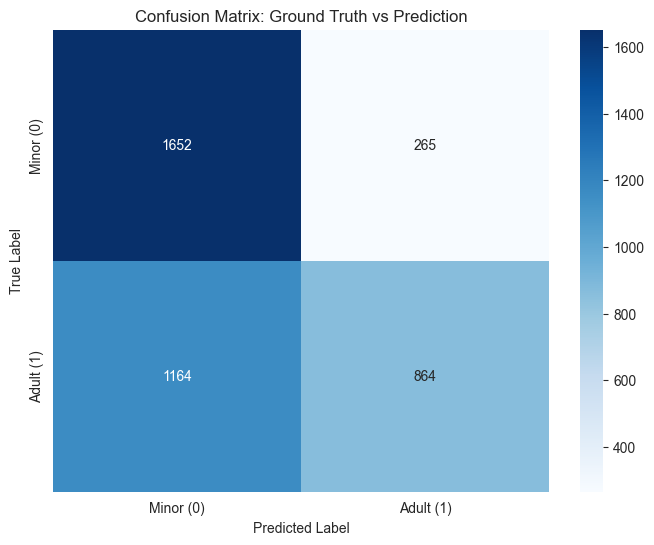

,name,image_path,age,dis,svm_score,prob_adult,pred_label,pred_class,true_label,true_class
0,1.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,-1.401035,0.197652,0,not_adult,0,not_adult
1,2.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,0.356116,0.588100,1,adult,0,not_adult
2,3.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,2,3.367549e-02 1.629141e-01 1.915395e-01 2.03727...,-0.846945,0.300074,0,not_adult,0,not_adult
3,4.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,-1.185882,0.233996,0,not_adult,0,not_adult
4,5.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,-0.166397,0.458497,0,not_adult,0,not_adult
...,...,...,...,...,...,...,...,...,...,...
3940,3941.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,5,1.108530e-03 4.384320e-03 1.350466e-02 3.23959...,-1.321210,0.210617,0,not_adult,0,not_adult
3941,3942.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,5,1.108530e-03 4.384320e-03 1.350466e-02 3.23959...,-0.300423,0.425454,0,not_adult,0,not_adult
3942,3943.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,7,3.345785e-05 2.181726e-04 1.107972e-03 4.38211...,-0.063415,0.484151,0,not_adult,0,not_adult
3943,3944.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,8,3.995938e-06 3.345758e-05 2.181708e-04 1.10796...,-0.699279,0.331972,0,not_adult,0,not_adult


In [6]:
rows, metrics = run_inference(records=records, bundle=bundle, config=CONFIG)

pred_csv_path = out_dir / 'test_predictions.csv'
pred_json_path = out_dir / 'test_predictions.json'
metrics_json_path = out_dir / 'test_metrics.json'

with pred_csv_path.open('w', newline='', encoding='utf-8') as file:
    if rows:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

with pred_json_path.open('w', encoding='utf-8') as file:
    json.dump(rows, file, indent=2)

if metrics is not None:
    with metrics_json_path.open('w', encoding='utf-8') as file:
        json.dump(metrics, file, indent=2)

print(f'Predictions CSV : {pred_csv_path}')
print(f'Predictions JSON: {pred_json_path}')

if metrics is not None:
    print(f'Metrics JSON    : {metrics_json_path}')
    print('\nTest metrics:')
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f'  {key}: {value:.6f}')
        else:
            print(f'  {key}: {value}')
else:
    print('\nNo test labels detected, so only inference results were saved.')

if metrics is not None:
    cm = confusion_matrix(
        [row['true_label'] for row in rows],
        [row['pred_label'] for row in rows],
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Minor (0)', 'Adult (1)'],
        yticklabels=['Minor (0)', 'Adult (1)'],
    )

    plt.title('Confusion Matrix: Ground Truth vs Prediction')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

if pd is not None:
    display(pd.DataFrame(rows))
else:
    rows[:10]
